<a href="https://colab.research.google.com/github/caroccialberto/Python2026/blob/main/lesson_matplotlib_pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Introduction to Data Visualisation in Python
### Topics: **Matplotlib** & **Pandas**

---
# 📈 Part 1 — Matplotlib (~35 min)

**Matplotlib** is the standard Python library for creating plots.  
We always import it with the short nickname `plt`.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np   # we also import NumPy for maths

print("Libraries ready ✅")

## 1.1 Line Plot

We measure the temperature every day for one week.  
`plt.plot(x, y)` draws a line, `plt.show()` displays it.

In [ ]:
days         = [1, 2, 3, 4, 5, 6, 7]
temperatures = [22, 25, 19, 30, 27, 24, 21]

plt.plot(days, temperatures, color="tomato", marker="o", linewidth=2)

plt.title("Weekly Temperature")
plt.xlabel("Day")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

### ⚡ Quick Practice 1: Your first line plot
Create a line plot of `y = x^2`.
We have provided the lists. Make the line **green** and use a **dashed** line style (`linestyle="--"`).


In [ ]:
x = [1, 2, 3, 4, 5]
y = [1, 4, 9, 16, 25]

# ✏️ Your code here:


## 1.2 Histogram

A **histogram** shows how values are *distributed* — how often each range of values appears.  
This is one of the most useful plots in data analysis.

In [ ]:
# Simulate 1000 exam scores (bell-curve distribution centred on 65)
np.random.seed(42)
scores = np.random.normal(loc=65, scale=12, size=1000)

plt.figure(figsize=(8, 4))
plt.hist(scores, bins=30, color="steelblue", edgecolor="white")

plt.title("Distribution of 1000 Exam Scores")
plt.xlabel("Score")
plt.ylabel("Number of students")
plt.axvline(scores.mean(), color="red", linestyle="--", label=f"Mean = {scores.mean():.1f}")
plt.legend()
plt.show()

## 1.3 Bar Chart

Bar charts compare **categories**.  
Let's look at average monthly rainfall.

In [ ]:
months   = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
rainfall = [55,  40,  60,  80,  70,  30]

plt.bar(months, rainfall, color="cornflowerblue")
plt.title("Average Monthly Rainfall")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.show()

### ⚡ Quick Practice 2: Bar Chart
Plot the quarterly sales data below using `plt.bar()`. Add a title!


In [ ]:
quarters = ["Q1", "Q2", "Q3", "Q4"]
sales    = [150, 200, 180, 220]

# ✏️ Your code here:


## 1.4 Scatter Plot

A scatter plot shows the relationship between **two numerical variables**.

In [ ]:
hours_studied = [1, 2, 3, 4, 5, 6, 7, 8]
exam_score    = [45, 52, 58, 65, 70, 78, 85, 92]

plt.scatter(hours_studied, exam_score, color="purple", s=80)

plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours studied")
plt.ylabel("Exam score")
plt.grid(True)
plt.show()

### ⚡ Quick Practice 3: Scatter Plot
Plot the height vs weight of 5 people using `plt.scatter()`.
Make the points **red** and set the size `s=100`.


In [ ]:
height = [160, 170, 180, 165, 175]
weight = [60,  75,  85,  65,  70 ]

# ✏️ Your code here:


## 1.5 Multiple Lines and Legend

Plot several lines at once with `plt.legend()` to label them.

In [ ]:
city_a = [22, 25, 19, 30, 27, 24, 21]
city_b = [15, 17, 14, 20, 18, 16, 13]

plt.figure(figsize=(9, 4))
plt.plot(days, city_a, marker="o", label="Rome",  color="tomato")
plt.plot(days, city_b, marker="s", label="Milan", color="steelblue")

plt.title("Weekly Temperature – Two Cities")
plt.xlabel("Day")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

## 1.6 The Logistic Map — Order vs Chaos

The **logistic map** is a simple rule for updating a population each time step:

$$x_{n+1} = r \cdot x_n \cdot (1 - x_n)$$

- $x_n \in [0,1]$ is the population fraction at step $n$
- $r \in [0,4]$ is the **growth parameter**

By simply changing $r$ the system can be calm (converging to a steady state) or **chaotic** (never repeating).


In [ ]:
def logistic_map(r, x0, n_steps):
    """Iterate the logistic map for n_steps steps, starting from x0."""
    x = x0
    trajectory = [x]
    for _ in range(n_steps):
        x = r * x * (1 - x)
        trajectory.append(x)
    return trajectory

n = 80
x0 = 0.2

# Three different behaviours
r_stable    = 2.8   # converges to a fixed point
r_period2   = 3.2   # oscillates between two values (period-2 cycle)
r_chaotic   = 3.9   # chaotic — unpredictable!

traj_stable  = logistic_map(r_stable,  x0, n)
traj_period2 = logistic_map(r_period2, x0, n)
traj_chaotic = logistic_map(r_chaotic, x0, n)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, traj, r, title, color in zip(
        axes,
        [traj_stable, traj_period2, traj_chaotic],
        [r_stable, r_period2, r_chaotic],
        ["Stable  (r = 2.8)", "Period-2  (r = 3.2)", "Chaotic  (r = 3.9)"],
        ["steelblue", "darkorange", "crimson"]):
    ax.plot(traj, color=color, linewidth=1.2)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Time step $n$")
    ax.grid(True, alpha=0.4)

axes[0].set_ylabel("Population $x_n$")
fig.suptitle("Logistic Map — Three Regimes", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 1.7 The Bifurcation Diagram — Seeing Chaos Emerge

By sweeping the parameter $r$ from 2.5 to 4.0 and recording all the long-term values $x$ visits,  
we get the iconic **bifurcation diagram** — one of the most famous images in science.


### ⚡ Exercise
Plot the histogram of the logistic map points $x_n$ for different values of the parameter $r$

In [ ]:
# --- Bifurcation diagram ---
n_r       = 1000    # number of r values to scan
n_discard = 500     # transient iterations to throw away
n_plot    = 200     # iterations to actually plot per r value

r_values = np.linspace(2.5, 4.0, n_r)

r_plot = []   # will hold the r value for each dot
x_plot = []   # will hold the corresponding x value

for r in r_values:
    x = 0.5                              # start from 0.5
    for _ in range(n_discard):           # warm up (discard transient)
        x = r * x * (1 - x)
    for _ in range(n_plot):              # collect long-term behaviour
        x = r * x * (1 - x)
        r_plot.append(r)
        x_plot.append(x)

plt.figure(figsize=(12, 5))
plt.plot(r_plot, x_plot, ",k", alpha=0.15)   # tiny black dots

plt.title("Bifurcation Diagram of the Logistic Map", fontsize=14)
plt.xlabel("Growth parameter  $r$")
plt.ylabel("Long-term population  $x$")
plt.axvline(3.0,  color="steelblue",  linestyle="--", alpha=0.6, label="Period-2 onset  r≈3.0")
plt.axvline(3.57, color="crimson",    linestyle="--", alpha=0.6, label="Chaos onset  r≈3.57")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 1.8 The Mandelbrot Set (Simple Loops)

The **Mandelbrot set** lives in the complex plane.  
For each complex number $c = a + bi$, we repeatedly apply the rule:

$$z_{n+1} = z_n^2 + c, \quad z_0 = 0$$

If $|z_n|$ stays small forever → $c$ **belongs** to the set.  
We check this by iterating up to 50 times.


In [ ]:
# --- Mandelbrot set (Simple Python version) ---

width  = 300   # fewer pixels so it runs fast in class
height = 200
max_iter = 50  # maximum iterations to check

# We will store the results in a list of lists (a grid)
image = []

print("Computing Mandelbrot set... please wait (approx 5 seconds)")

for y in range(height):
    row = []
    for x in range(width):
        # 1. Map pixel (x, y) to a complex number c = a + bi
        a = -2.5 + (x / width)  * 3.5
        b = -1.2 + (y / height) * 2.4
        c = complex(a, b)

        # 2. Iterate the sequence z = z^2 + c
        z = 0
        iterations = 0

        while abs(z) <= 2 and iterations < max_iter:
            z = z*z + c
            iterations += 1

        # 3. Store the number of iterations
        row.append(iterations)

    image.append(row)

print("Done! Now plotting...")

# Plot the result
plt.figure(figsize=(10, 7))
plt.imshow(image, cmap="inferno", extent=[-2.5, 1.0, -1.2, 1.2])
plt.colorbar(label="Iterations")
plt.title("The Mandelbrot Set")
plt.xlabel("Real axis (a)")
plt.ylabel("Imaginary axis (b)")
plt.show()

**How this works:**
- We loop over every pixel `(x, y)`
- We convert the pixel coordinate to a complex number `c`
- We run the `while` loop to see if `z` escapes (gets larger than 2)
- We colour the pixel based on how many iterations it took to escape

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Setup the common Growth Parameter (r) axis
# ==========================================
r_min, r_max = 2.4, 4.0
width, height = 1000, 400

# Create the r values (x-axis) and imaginary values (y-axis)
r_vals = np.linspace(r_min, r_max, width)
y_vals = np.linspace(-0.25, 0.25, height)

# ==========================================
# 2. Compute the Mandelbrot Set (Mapped to r)
# ==========================================
# We map the logistic 'r' parameter to the Mandelbrot 'c' parameter:
# c = r/2 * (1 - r/2) + imaginary_part
R, Y = np.meshgrid(r_vals, y_vals)
C = (R/2) * (1 - R/2) + 1j * Y

Z = np.zeros_like(C)
M = np.zeros(C.shape, dtype=int)
max_iter = 50

for i in range(max_iter):
    mask = np.abs(Z) <= 2
    Z[mask] = Z[mask]**2 + C[mask]
    M[mask] += 1

# ==========================================
# 3. Compute the Logistic Map Bifurcation
# ==========================================
n_r = 1000
n_discard = 200
n_plot = 100

r_logistic = np.linspace(r_min, r_max, n_r)
r_points, x_points = [], []

for r in r_logistic:
    x = 0.5
    for _ in range(n_discard):      # Discard early transients
        x = r * x * (1 - x)
    for _ in range(n_plot):         # Record long-term behavior
        x = r * x * (1 - x)
        r_points.append(r)
        x_points.append(x)

# ==========================================
# 4. Plot both side-by-side (vertically stacked)
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Top Plot: Mandelbrot
ax1.imshow(M, extent=[r_min, r_max, -0.25, 0.25], aspect='auto', cmap='inferno', origin='lower')
ax1.set_title("Mandelbrot Set (Mapped to Logistic Growth Parameter 'r')")
ax1.set_ylabel("Imaginary Part of c")

# Bottom Plot: Logistic Map
ax2.plot(r_points, x_points, ',k', alpha=0.25) # ',k' means tiny black dots
ax2.set_title("Logistic Map Bifurcation Diagram")
ax2.set_ylabel("Population Fraction (x)")
ax2.set_xlabel("Growth Parameter (r)")

# Add dashed alignment lines to show the connection
for r_val in [3.0, 3.449, 3.5699, 3.83]:
    ax1.axvline(r_val, color='white', linestyle='--', alpha=0.5)
    ax2.axvline(r_val, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


An example of 3D visualization using other plotting tools

In [1]:
import numpy as np
import plotly.graph_objects as go

print("Calculating 3D geometry... this takes a few seconds.")

# ==========================================
# 1. Mandelbrot Set (The Floor: Z = 0)
# ==========================================
r_min, r_max = 2.4, 4.0
width, height = 400, 200

r_vals = np.linspace(r_min, r_max, width)
y_vals = np.linspace(-0.25, 0.25, height)
R, Y = np.meshgrid(r_vals, y_vals)

# Map Logistic 'r' to Mandelbrot 'c'
C = (R/2) * (1 - R/2) + 1j * Y
Z_c = np.zeros_like(C)
M = np.zeros(C.shape, dtype=int)
max_iter = 40

for i in range(max_iter):
    mask = np.abs(Z_c) <= 2
    Z_c[mask] = Z_c[mask]**2 + C[mask]
    M[mask] += 1

Z_floor = np.zeros_like(R)  # The floor sits exactly at altitude 0

# Create the floor surface
surface = go.Surface(
    x=R, y=Y, z=Z_floor,
    surfacecolor=M,           # Color based on iteration count
    colorscale='Magma',
    showscale=False,
    opacity=0.85,
    hoverinfo='skip'
)

# ==========================================
# 2. Bifurcation Diagram (The Wall: Y = 0)
# ==========================================
n_r = 800
n_discard = 200
n_plot = 60

r_logistic = np.linspace(r_min, r_max, n_r)
r_points, y_points, x_points = [], [], []

for r in r_logistic:
    x = 0.5
    for _ in range(n_discard):
        x = r * x * (1 - x)
    for _ in range(n_plot):
        x = r * x * (1 - x)
        r_points.append(r)
        y_points.append(0.0)  # Always right down the middle
        x_points.append(x)

# Create the 3D scatter points
scatter = go.Scatter3d(
    x=r_points, y=y_points, z=x_points,
    mode='markers',
    marker=dict(size=1.5, color='cyan', opacity=0.5),
    hoverinfo='skip'
)

# ==========================================
# 3. Build and Show the Interactive Figure
# ==========================================
fig = go.Figure(data=[surface, scatter])

fig.update_layout(
    title="3D Logistic Map Emerging from the Mandelbrot Set",
    template="plotly_dark",   # Dark mode makes the colors pop
    scene=dict(
        xaxis_title="Growth Parameter (r)",
        yaxis_title="Imaginary Part of c",
        zaxis_title="Population Fraction",
        xaxis=dict(range=[2.4, 4.0]),
        yaxis=dict(range=[-0.25, 0.25]),
        zaxis=dict(range=[0, 1]),
        camera=dict(
            eye=dict(x=-1.5, y=-1.5, z=0.8) # Elegant starting angle
        )
    ),
    margin=dict(l=0, r=0, b=0, t=50) # Remove extra whitespace
)

print("Done! Click and drag to rotate.")
fig.show()


Calculating 3D geometry... this takes a few seconds.
Done! Click and drag to rotate.


---
# 🐼 Part 2 — Pandas

**Pandas** is the standard Python library for working with **tabular data**.  
Its main object is the **DataFrame** — a table with rows and columns, like a spreadsheet.

We will work with the **Iris dataset** — one of the most famous datasets in data science.  
It contains measurements of 150 iris flowers from three species.


In [44]:
import pandas as pd
import matplotlib.pyplot as plt


print("Pandas version:", pd.__version__, "✅")

Pandas version: 2.2.2 ✅


## 2.1 Loading a Real Dataset from the Web

`pd.read_csv(url)` can load a CSV file directly from a URL — no download needed.

In [5]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"

df = pd.read_csv(url)

print("Dataset loaded! Shape:", df.shape)  # (rows, columns)
df.head()   # show first 5 rows

Dataset loaded! Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/14UyGTuYGll3nf_Y9ZmN-8pUCbhkruj6u877KCNRJXnc/edit#gid=0


## 2.2 Exploring the Data

In [8]:
# Quick statistical summary of all numerical columns
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [9]:
# How many flowers per species?
df["species"].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50




```
# This is formatted as code
```

### ⚡ Quick Practice 4: Explore
Use `.tail(3)` to see the last 3 rows of the dataset `df`.


In [10]:
# ✏️ Your code here:
df.tail(3)

,sepal_length,sepal_width,petal_length,petal_width,species
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


## 2.3 Selecting Columns and Filtering Rows

**Select a column** with `df["column_name"]` — you get a Series.  
**Filter rows** by writing a condition inside `df[...]`.

In [11]:
# Single column
df["petal_length"]

,petal_length
0,1.4
1,1.4
2,1.3
3,1.5
4,1.4
...,...
145,5.2
146,5.0
147,5.2
148,5.4


In [12]:
# Keep only setosa flowers
setosa = df[df["species"] == "setosa"]
print("Number of setosa rows:", len(setosa))
setosa.head()

Number of setosa rows: 50


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### ⚡ Quick Practice 5: Filter
Filter the DataFrame to find only the flowers where `sepal_length` is greater than `7.5`.
Assign it to a variable called `giant_flowers` and print it!


In [16]:
# ✏️ Your code here:
giant_flowers = df[df["sepal_length"] > 7.5]
print(giant_flowers)

     sepal_length  sepal_width  petal_length  petal_width    species
105           7.6          3.0           6.6          2.1  virginica
117           7.7          3.8           6.7          2.2  virginica
118           7.7          2.6           6.9          2.3  virginica
122           7.7          2.8           6.7          2.0  virginica
131           7.9          3.8           6.4          2.0  virginica
135           7.7          3.0           6.1          2.3  virginica


## 2.4 Adding a New Column

In [17]:
# Ratio of petal length to petal width
df["petal_ratio"] = df["petal_length"] / df["petal_width"]

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,petal_ratio
0,5.1,3.5,1.4,0.2,setosa,7.0
1,4.9,3.0,1.4,0.2,setosa,7.0
2,4.7,3.2,1.3,0.2,setosa,6.5
3,4.6,3.1,1.5,0.2,setosa,7.5
4,5.0,3.6,1.4,0.2,setosa,7.0


### ⚡ Quick Practice 6: Math with Columns
Create a new column called `"sepal_sum"` that adds the `sepal_length` and `sepal_width` together. Then show the `.head()`.


In [18]:
# ✏️ Your code here:
df["sepal_sum"] = df['sepal_length'] + df['sepal_width']
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,petal_ratio,sepal_sum
0,5.1,3.5,1.4,0.2,setosa,7.0,8.6
1,4.9,3.0,1.4,0.2,setosa,7.0,7.9
2,4.7,3.2,1.3,0.2,setosa,6.5,7.9
3,4.6,3.1,1.5,0.2,setosa,7.5,7.7
4,5.0,3.6,1.4,0.2,setosa,7.0,8.6


## 2.5 GroupBy — Statistics per Species

`groupby("column")` splits the table by category, then you apply any aggregation function.

In [19]:
# Mean of all measurements, grouped by species
df.groupby("species")[["sepal_length", "sepal_width",
                        "petal_length", "petal_width"]].mean().round(2)

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


### ⚡ Quick Practice 7: GroupBy
Find the **maximum** (`.max()`) of the `petal_length` for each species.


In [37]:
# ✏️ Your code here:
df.groupby("species")[["petal_length"]].std().round(3)

,petal_length
species,
setosa,0.174
versicolor,0.470
virginica,0.552


## 2.6 Sorting

In [22]:
# Top 5 flowers with the longest petals
df.sort_values("petal_length", ascending=False).head(5)

,sepal_length,sepal_width,petal_length,petal_width,species,petal_ratio,sepal_sum
118,7.7,2.6,6.9,2.3,virginica,3.000000,10.3
117,7.7,3.8,6.7,2.2,virginica,3.045455,11.5
122,7.7,2.8,6.7,2.0,virginica,3.350000,10.5
105,7.6,3.0,6.6,2.1,virginica,3.142857,10.6
131,7.9,3.8,6.4,2.0,virginica,3.200000,11.7


## 2.7 Visualising the Iris Data

Pandas `.plot()` calls Matplotlib automatically — perfect for quick exploration.

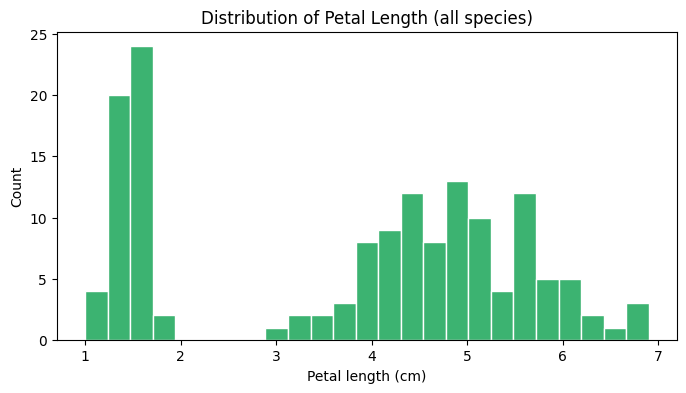

In [45]:
# Histogram of petal lengths — do we see different groups?
df["petal_length"].plot(kind="hist", bins=25, color="mediumseagreen",
                        edgecolor="white", figsize=(8, 4))


plt.title("Distribution of Petal Length (all species)")
plt.xlabel("Petal length (cm)")
plt.ylabel("Count")
plt.show()

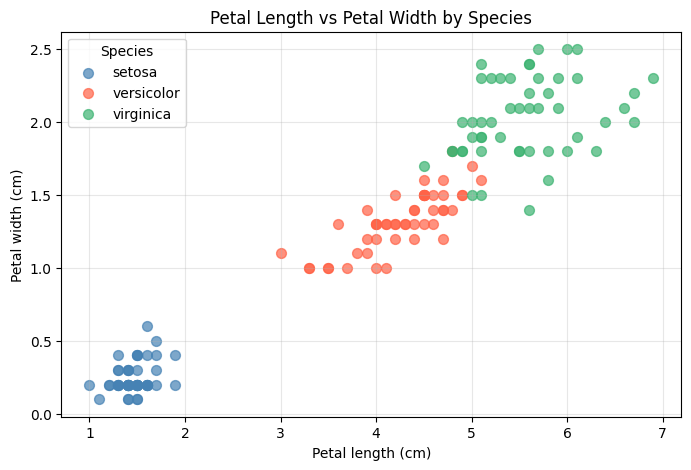

In [46]:
# Scatter plot: petal length vs petal width, coloured by species
species_list  = df["species"].unique()
colours       = ["steelblue", "tomato", "mediumseagreen"]

plt.figure(figsize=(8, 5))
for sp, col in zip(species_list, colours):
    subset = df[df["species"] == sp]
    plt.scatter(subset["petal_length"], subset["petal_width"],
                label=sp, color=col, alpha=0.7, s=50)

plt.title("Petal Length vs Petal Width by Species")
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.legend(title="Species")
plt.grid(True, alpha=0.3)
plt.show()

**What the scatter plot tells us:**  
- The three species form **well-separated clusters** in petal space  
- *Setosa* has tiny petals (bottom-left); *virginica* has the largest petals (top-right)

## 🎓 Final Challenge

Combine what you have learned!

1. **Filter** the DataFrame to keep only flowers where `species == "virginica"`
2. **Plot a scatter plot** of `sepal_length` (x-axis) vs `sepal_width` (y-axis) for those filtered flowers.
3. Make the scatter points **orange** and add a title!


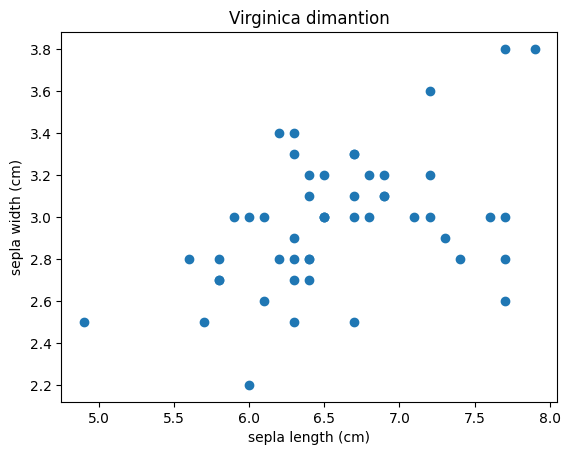

In [50]:
# ✏️ Your code here

# step 1
virginica = df[df["species"] == "virginica"]

# step 2
plt.scatter(virginica["sepal_length"],virginica["sepal_width"])
# step 3
plt.title("Virginica dimantion")
plt.xlabel("sepla length (cm)")
plt.ylabel("sepla width (cm)")
plt.show()
